# Análisis de diversidad para suelos con metadata

Versión final ajustada.

Este notebook adapta el análisis para los archivos `suelos1.biom`, `suelos2.biom`, `suelos3.biom` y sus metadatos.

Estructura esperada del proyecto:

```
tu_proyecto/
├── analisis_suelos_con_metadata_final_muestras_unificadas.ipynb
├── data/
│   ├── suelos1.biom
│   ├── suelos2.biom
│   ├── suelos3.biom
│   ├── metadata_suelos1.csv
│   ├── metadata_suelos2.csv
│   └── metadata_suelos3.csv
├── plots/
└── resultados_suelos/
```

Puntos importantes:
- Los `.biom` tienen 3 columnas por muestra: `GTDB`, `PlusPFP` y `EuPathDB`.
- Como Kraken fue corrido de forma secuencial, esas 3 columnas se tratan como **la misma muestra biológica**.
- El notebook suma automáticamente `luciana_XX_GTDB`, `luciana_XX_PlusPFP` y `luciana_XX_EuPathDB` en una sola columna `luciana_XX`.
- El metadata se une usando el ID base (`luciana_09`, etc.).
- En las gráficas se usa la columna `nombre` del metadata como etiqueta de muestra cuando está disponible.
- Todas las gráficas se guardan automáticamente en `plots/` como `.png` y `.svg`.
- Las tablas/resultados se guardan en `resultados_suelos/`.


In [3]:
# Código revisado
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/Luciana/data")
PLOTS_DIR = Path("/content/drive/MyDrive/Luciana/output/plots")
OUTPUT_DIR = Path("/content/drive/MyDrive/Luciana/output/resultados_suelos")

# Si no existe data/, usa el directorio actual como respaldo.
# Esto ayuda cuando los archivos están junto al notebook.
if not DATA_DIR.exists():
    print("⚠️ No encontré la carpeta data/. Usaré el directorio actual.")
    DATA_DIR = Path(".")

PLOTS_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Carpeta de datos: {DATA_DIR.resolve()}")
print(f"Carpeta de plots: {PLOTS_DIR.resolve()}")
print(f"Carpeta de resultados: {OUTPUT_DIR.resolve()}")


Carpeta de datos: /content/drive/MyDrive/Luciana/data
Carpeta de plots: /content/drive/MyDrive/Luciana/output/plots
Carpeta de resultados: /content/drive/MyDrive/Luciana/output/resultados_suelos


In [5]:
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import entropy
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS
from sklearn.decomposition import TruncatedSVD

warnings.filterwarnings("ignore")

# Archivos esperados dentro de data/
BIOM_FILES = {
    "suelos1": DATA_DIR / "suelos1.biom",
    "suelos2": DATA_DIR / "suelos2.biom",
    "suelos3": DATA_DIR / "suelos3.biom",
}

METADATA_FILES = {
    "suelos1": DATA_DIR / "metadata_suelos1.csv",
    "suelos2": DATA_DIR / "metadata_suelos2.csv",
    "suelos3": DATA_DIR / "metadata_suelos3.csv",
}

missing_files = [str(p) for p in list(BIOM_FILES.values()) + list(METADATA_FILES.values()) if not p.exists()]
if missing_files:
    raise FileNotFoundError(
        "No encontré estos archivos. Colócalos dentro de la carpeta data/:\n" + "\n".join(missing_files)
    )

def save_plot(fig, name, dpi=300):
    """Guarda una figura en plots/ como PNG y SVG."""
    safe_name = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(name)).strip("_")
    png_path = PLOTS_DIR / f"{safe_name}.png"
    svg_path = PLOTS_DIR / f"{safe_name}.svg"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    print(f"Guardado: {png_path}")
    print(f"Guardado: {svg_path}")

print("Listo.")


Listo.


## 1. Cargar metadata

In [6]:
def load_metadata(metadata_files):
    frames = []
    for dataset, path in metadata_files.items():
        df = pd.read_csv(path)
        df["dataset"] = dataset
        frames.append(df)
    metadata = pd.concat(frames, ignore_index=True)
    metadata["sample"] = metadata["sample"].astype(str)
    return metadata

metadata = load_metadata(METADATA_FILES)
print(metadata.shape)
display(metadata.head())
print(metadata.columns.tolist())

(36, 16)


,sample,nombre,fertilizer,tratamiento,estudio,fungicide,pesticide,herbicide,plant,ph,org_matter,temp,plant_growth_med,plant_water_method,experiment,dataset
0,luciana_09,BAB1_S5,Compost,Agroecológico,1,sulfocalcium_Fungifree_bordocop,Beauveria_Dipel_Trichoderma_Bt,Weeding,brocoli,NaN,NaN,NaN,soil,drip,1.0,suelos1
1,luciana_10,BAB2_S6,Compost,Agroecológico,1,sulfocalcium_Fungifree_bordocop,Beauveria_Dipel_Trichoderma_Bt,Weeding,brocoli,NaN,NaN,NaN,soil,drip,1.0,suelos1
2,luciana_11,BAB3_S7,Compost,Agroecológico,1,sulfocalcium_Fungifree_bordocop,Beauveria_Dipel_Trichoderma_Bt,Weeding,brocoli,NaN,NaN,NaN,soil,drip,1.0,suelos1
3,luciana_12,BAB4_S8,Compost,Agroecológico,1,sulfocalcium_Fungifree_bordocop,Beauveria_Dipel_Trichoderma_Bt,Weeding,brocoli,NaN,NaN,NaN,soil,drip,1.0,suelos1
4,luciana_14,CeAB1_S9,Compost,Agroecológico,1,sulfocalcium_Fungifree_bordocop,Beauveria_Dipel_Trichoderma_Bt,Weeding,cempazuchitl,NaN,NaN,NaN,soil,drip,1.0,suelos1


['sample', 'nombre', 'fertilizer', 'tratamiento', 'estudio', 'fungicide', 'pesticide', 'herbicide', 'plant', 'ph', 'org_matter', 'temp', 'plant_growth_med', 'plant_water_method', 'experiment', 'dataset']


## 2. Cargar BIOM y construir tabla OTU/feature

In [7]:
DB_SUFFIX_RE = re.compile(r"_(EuPathDB|GTDB|PlusPFP)$")

# Orden solo informativo del procesamiento secuencial
DATABASE_ORDER = ["GTDB", "PlusPFP", "EuPathDB"]

def split_sample_id(sample_id):
    """Devuelve sample_base y database desde IDs como luciana_09_EuPathDB."""
    m = DB_SUFFIX_RE.search(sample_id)
    if m:
        database = m.group(1)
        sample_base = sample_id[:m.start()]
    else:
        database = "unknown"
        sample_base = sample_id
    return sample_base, database

def load_biom_as_df(path):
    """
    Carga un BIOM JSON sparse v1.

    Importante:
    - En el BIOM cada muestra aparece como luciana_XX_GTDB, luciana_XX_PlusPFP y luciana_XX_EuPathDB.
    - Como estos resultados vienen del mismo flujo secuencial de Kraken, se suman por sample_base.
    - La tabla final queda con una sola columna por muestra: luciana_XX.
    """
    with open(path, "r") as f:
        biom_data = json.load(f)

    columns = biom_data.get("columns", [])
    rows = biom_data.get("rows", [])
    data = biom_data.get("data", [])

    sample_ids = [col.get("id") for col in columns]
    otu_ids = [str(row.get("id")) for row in rows]

    matrix = np.zeros((len(rows), len(columns)), dtype=np.float32)
    for otu_idx, sample_idx, count in data:
        matrix[otu_idx, sample_idx] = count

    otu_raw = pd.DataFrame(matrix, index=otu_ids, columns=sample_ids)

    sample_info_raw = pd.DataFrame({"sample_full": sample_ids})
    split = sample_info_raw["sample_full"].apply(split_sample_id)
    sample_info_raw["sample"] = split.apply(lambda x: x[0])
    sample_info_raw["database"] = split.apply(lambda x: x[1])

    # Unificar las columnas que pertenecen a la misma muestra biológica.
    # Ejemplo: luciana_29_GTDB + luciana_29_PlusPFP + luciana_29_EuPathDB -> luciana_29
    rename_map = dict(zip(sample_info_raw["sample_full"], sample_info_raw["sample"]))
    otu_df = otu_raw.rename(columns=rename_map).T.groupby(level=0).sum().T

    # Una fila por muestra biológica, conservando de qué bases venía.
    sample_info = (
        sample_info_raw
        .groupby("sample", as_index=False)
        .agg(
            source_columns=("sample_full", lambda x: ";".join(map(str, x))),
            databases_detected=("database", lambda x: ";".join([db for db in DATABASE_ORDER if db in set(x)] + sorted(set(x) - set(DATABASE_ORDER))))
        )
    )

    taxonomy_records = []
    for row in rows:
        tax = row.get("metadata", {}).get("taxonomy", [])
        if not isinstance(tax, list):
            tax = [str(tax)]
        taxonomy_records.append({
            "feature_id": str(row.get("id")),
            "taxonomy": "; ".join(tax),
            "kingdom": tax[0] if len(tax) > 0 else "Unclassified",
            "phylum": tax[1] if len(tax) > 1 else "Unclassified",
            "class": tax[2] if len(tax) > 2 else "Unclassified",
            "order": tax[3] if len(tax) > 3 else "Unclassified",
            "family": tax[4] if len(tax) > 4 else "Unclassified",
            "genus": tax[5] if len(tax) > 5 else "Unclassified",
            "species": tax[6] if len(tax) > 6 else "Unclassified",
        })
    taxonomy_df = pd.DataFrame(taxonomy_records).drop_duplicates("feature_id")

    return otu_df, taxonomy_df, sample_info, sample_info_raw

otu_tables = {}
taxonomy_tables = {}
sample_info_frames = []
sample_info_raw_frames = []

for dataset, path in BIOM_FILES.items():
    otu_df, tax_df, sample_info, sample_info_raw = load_biom_as_df(path)
    otu_tables[dataset] = otu_df
    taxonomy_tables[dataset] = tax_df
    sample_info["dataset"] = dataset
    sample_info_raw["dataset"] = dataset
    sample_info_frames.append(sample_info)
    sample_info_raw_frames.append(sample_info_raw)

sample_info_all = pd.concat(sample_info_frames, ignore_index=True)
sample_info_raw_all = pd.concat(sample_info_raw_frames, ignore_index=True)

print("Tablas cargadas y muestras unificadas:")
for dataset, df in otu_tables.items():
    print(f"- {dataset}: {df.shape[0]:,} features x {df.shape[1]:,} muestras biológicas")

display(sample_info_all.head())
sample_info_raw_all.to_csv(OUTPUT_DIR / "sample_info_columnas_originales_biom.csv", index=False)
print("Guardado:", OUTPUT_DIR / "sample_info_columnas_originales_biom.csv")


Tablas cargadas y muestras unificadas:
- suelos1: 156,580 features x 24 muestras biológicas
- suelos2: 98,211 features x 10 muestras biológicas
- suelos3: 36,998 features x 2 muestras biológicas


,sample,source_columns,databases_detected,dataset
0,luciana_01,luciana_01_EuPathDB;luciana_01_GTDB;luciana_01...,GTDB;PlusPFP;EuPathDB,suelos1
1,luciana_02,luciana_02_EuPathDB;luciana_02_GTDB;luciana_02...,GTDB;PlusPFP;EuPathDB,suelos1
2,luciana_03,luciana_03_EuPathDB;luciana_03_GTDB;luciana_03...,GTDB;PlusPFP;EuPathDB,suelos1
3,luciana_04,luciana_04_EuPathDB;luciana_04_GTDB;luciana_04...,GTDB;PlusPFP;EuPathDB,suelos1
4,luciana_05,luciana_05_EuPathDB;luciana_05_GTDB;luciana_05...,GTDB;PlusPFP;EuPathDB,suelos1


Guardado: /content/drive/MyDrive/Luciana/output/resultados_suelos/sample_info_columnas_originales_biom.csv


## 3. Unir metadata con las columnas del BIOM

In [8]:
sample_metadata = sample_info_all.merge(
    metadata,
    on=["dataset", "sample"],
    how="left",
    validate="many_to_one"
)

missing = sample_metadata[sample_metadata["nombre"].isna()][["dataset", "sample", "source_columns", "databases_detected"]]
print(f"Muestras BIOM sin metadata: {len(missing)}")
if len(missing):
    display(missing)

display(sample_metadata.head())
sample_metadata.to_csv(OUTPUT_DIR / "sample_metadata_unida.csv", index=False)
print("Guardado:", OUTPUT_DIR / "sample_metadata_unida.csv")


Muestras BIOM sin metadata: 0


,sample,source_columns,databases_detected,dataset,nombre,fertilizer,tratamiento,estudio,fungicide,pesticide,herbicide,plant,ph,org_matter,temp,plant_growth_med,plant_water_method,experiment
0,luciana_01,luciana_01_EuPathDB;luciana_01_GTDB;luciana_01...,GTDB;PlusPFP;EuPathDB,suelos1,BIB1_S8,phosphonitrate_compost,Integrado,1,Manzate_Clorotalonil,Beauveria_Dipel_Trichoderma_Decis_Bt,Weeding,brocoli,NaN,NaN,NaN,soil,drip,1.0
1,luciana_02,luciana_02_EuPathDB;luciana_02_GTDB;luciana_02...,GTDB;PlusPFP;EuPathDB,suelos1,JAB1_S5,Compost,Agroecológico,1,sulfocalcium_Fungifree_bordocop,Beauveria_Dipel_Trichoderma_Bt,Weeding,tomato,NaN,NaN,NaN,soil,drip,1.0
2,luciana_03,luciana_03_EuPathDB;luciana_03_GTDB;luciana_03...,GTDB;PlusPFP;EuPathDB,suelos1,JAB3_S6,Compost,Agroecológico,1,sulfocalcium_Fungifree_bordocop,Beauveria_Dipel_Trichoderma_Bt,Weeding,tomato,NaN,NaN,NaN,soil,drip,1.0
3,luciana_04,luciana_04_EuPathDB;luciana_04_GTDB;luciana_04...,GTDB;PlusPFP;EuPathDB,suelos1,JAB4_S7,Compost,Agroecológico,1,sulfocalcium_Fungifree_bordocop,Beauveria_Dipel_Trichoderma_Bt,Weeding,tomato,NaN,NaN,NaN,soil,drip,1.0
4,luciana_05,luciana_05_EuPathDB;luciana_05_GTDB;luciana_05...,GTDB;PlusPFP;EuPathDB,suelos1,JCB1_S1,phosphonitrate,Convencional,1,Manzate_Clorotalonil,Imidacloprid,Weeding,tomato,NaN,NaN,NaN,soil,drip,1.0


Guardado: /content/drive/MyDrive/Luciana/output/resultados_suelos/sample_metadata_unida.csv


## 4. Calcular diversidad alpha

In [9]:
def calculate_alpha_diversity(otu_table_df):
    alpha_metrics = []

    for sample in otu_table_df.columns:
        counts = otu_table_df[sample].values.astype(float)
        total_reads = counts.sum()
        observed = np.sum(counts > 0)

        if total_reads > 0:
            proportions = counts[counts > 0] / total_reads
            shannon = entropy(proportions)
            simpson = 1 - np.sum(proportions ** 2)
            pielou = shannon / np.log(observed) if observed > 1 else 0
        else:
            shannon = np.nan
            simpson = np.nan
            pielou = np.nan

        alpha_metrics.append({
            "sample": sample,
            "total_reads": total_reads,
            "observed": observed,
            "shannon": shannon,
            "simpson": simpson,
            "pielou_evenness": pielou,
        })

    return pd.DataFrame(alpha_metrics)

alpha_frames = []
for dataset, otu_df in otu_tables.items():
    alpha = calculate_alpha_diversity(otu_df)
    alpha["dataset"] = dataset
    alpha_frames.append(alpha)

alpha_diversity = pd.concat(alpha_frames, ignore_index=True)
alpha_diversity = alpha_diversity.merge(sample_metadata, on=["dataset", "sample"], how="left")

display(alpha_diversity.head())
alpha_diversity.to_csv(OUTPUT_DIR / "alpha_diversity_con_metadata.csv", index=False)
print("Guardado:", OUTPUT_DIR / "alpha_diversity_con_metadata.csv")


,sample,total_reads,observed,shannon,simpson,pielou_evenness,dataset,source_columns,databases_detected,nombre,...,fungicide,pesticide,herbicide,plant,ph,org_matter,temp,plant_growth_med,plant_water_method,experiment
0,luciana_01,299603.0,65100,9.576972,0.999412,0.864061,suelos1,luciana_01_EuPathDB;luciana_01_GTDB;luciana_01...,GTDB;PlusPFP;EuPathDB,BIB1_S8,...,Manzate_Clorotalonil,Beauveria_Dipel_Trichoderma_Decis_Bt,Weeding,brocoli,NaN,NaN,NaN,soil,drip,1.0
1,luciana_02,783435.0,94626,9.738737,0.999365,0.849974,suelos1,luciana_02_EuPathDB;luciana_02_GTDB;luciana_02...,GTDB;PlusPFP;EuPathDB,JAB1_S5,...,sulfocalcium_Fungifree_bordocop,Beauveria_Dipel_Trichoderma_Bt,Weeding,tomato,NaN,NaN,NaN,soil,drip,1.0
2,luciana_03,537074.0,83008,9.656433,0.999252,0.852538,suelos1,luciana_03_EuPathDB;luciana_03_GTDB;luciana_03...,GTDB;PlusPFP;EuPathDB,JAB3_S6,...,sulfocalcium_Fungifree_bordocop,Beauveria_Dipel_Trichoderma_Bt,Weeding,tomato,NaN,NaN,NaN,soil,drip,1.0
3,luciana_04,311784.0,67675,9.645513,0.999443,0.867209,suelos1,luciana_04_EuPathDB;luciana_04_GTDB;luciana_04...,GTDB;PlusPFP;EuPathDB,JAB4_S7,...,sulfocalcium_Fungifree_bordocop,Beauveria_Dipel_Trichoderma_Bt,Weeding,tomato,NaN,NaN,NaN,soil,drip,1.0
4,luciana_05,1074170.0,38210,6.378527,0.979989,0.604551,suelos1,luciana_05_EuPathDB;luciana_05_GTDB;luciana_05...,GTDB;PlusPFP;EuPathDB,JCB1_S1,...,Manzate_Clorotalonil,Imidacloprid,Weeding,tomato,NaN,NaN,NaN,soil,drip,1.0


Guardado: /content/drive/MyDrive/Luciana/output/resultados_suelos/alpha_diversity_con_metadata.csv


## 5. Visualizar alpha diversidad por metadata

Guardado: /content/drive/MyDrive/Luciana/output/plots/alpha_shannon_por_tratamiento.png
Guardado: /content/drive/MyDrive/Luciana/output/plots/alpha_shannon_por_tratamiento.svg


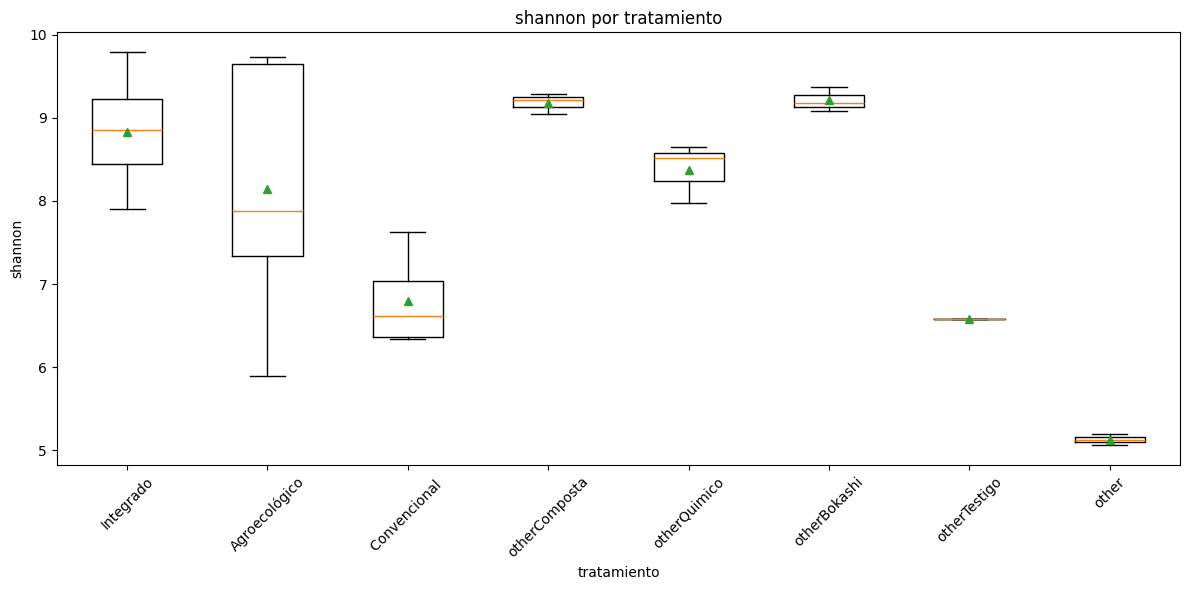

Guardado: /content/drive/MyDrive/Luciana/output/plots/alpha_observed_por_tratamiento.png
Guardado: /content/drive/MyDrive/Luciana/output/plots/alpha_observed_por_tratamiento.svg


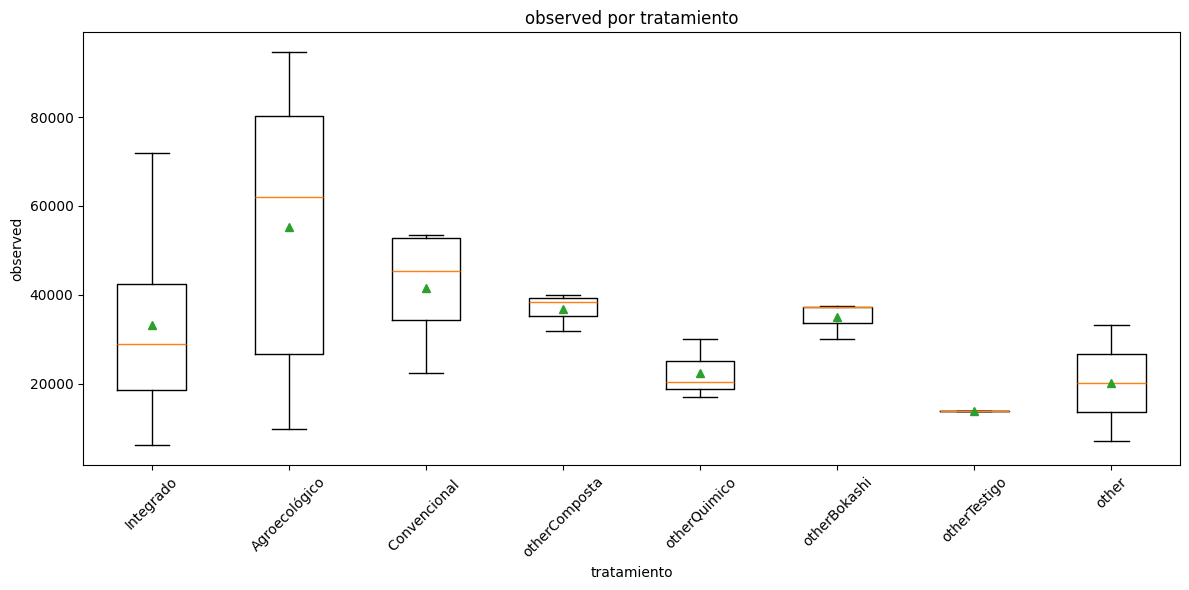

In [10]:
def plot_alpha_box(metric="shannon", group_col="tratamiento"):
    df = alpha_diversity.dropna(subset=[metric, group_col]).copy()
    if df.empty:
        print(f"No hay datos suficientes para {metric} por {group_col}")
        return

    groups = list(df[group_col].astype(str).unique())
    values = [df.loc[df[group_col].astype(str) == g, metric].values for g in groups]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.boxplot(values, labels=groups, showmeans=True)
    ax.set_title(f"{metric} por {group_col}")
    ax.set_xlabel(group_col)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    save_plot(fig, f"alpha_{metric}_por_{group_col}")
    plt.show()

plot_alpha_box("shannon", "tratamiento")
plot_alpha_box("observed", "tratamiento")


## 6. Beta diversidad Bray-Curtis y ordenación MDS

Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos1_mds_braycurtis_por_tratamiento.png
Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos1_mds_braycurtis_por_tratamiento.svg


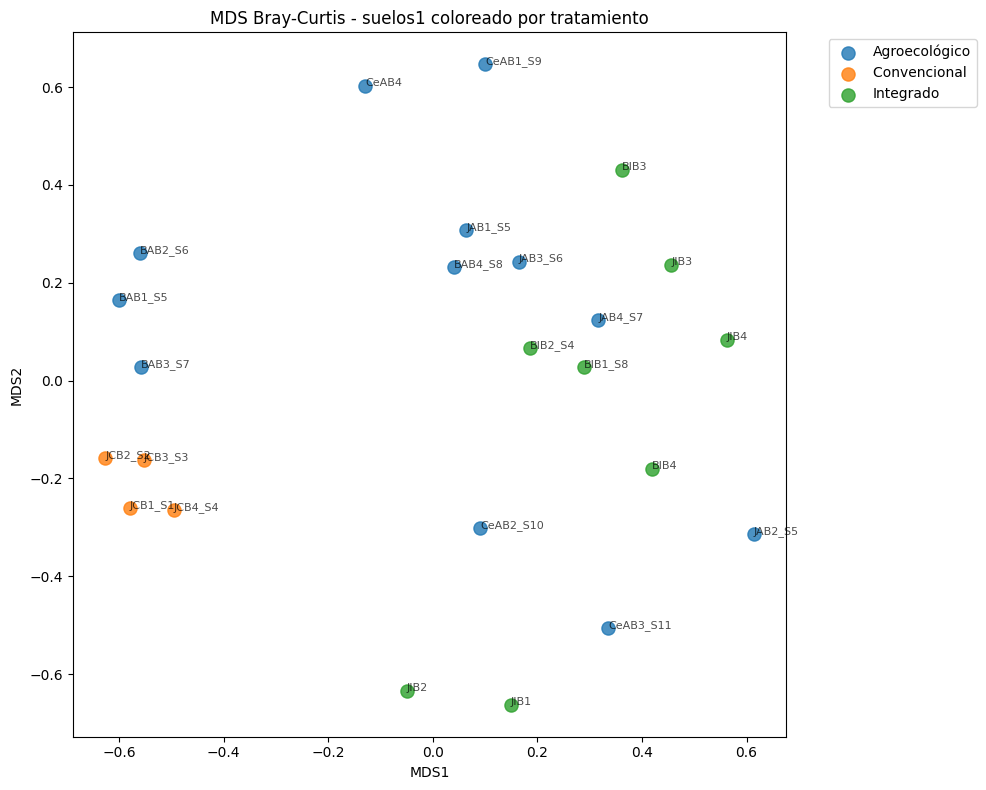

Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos2_mds_braycurtis_por_tratamiento.png
Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos2_mds_braycurtis_por_tratamiento.svg


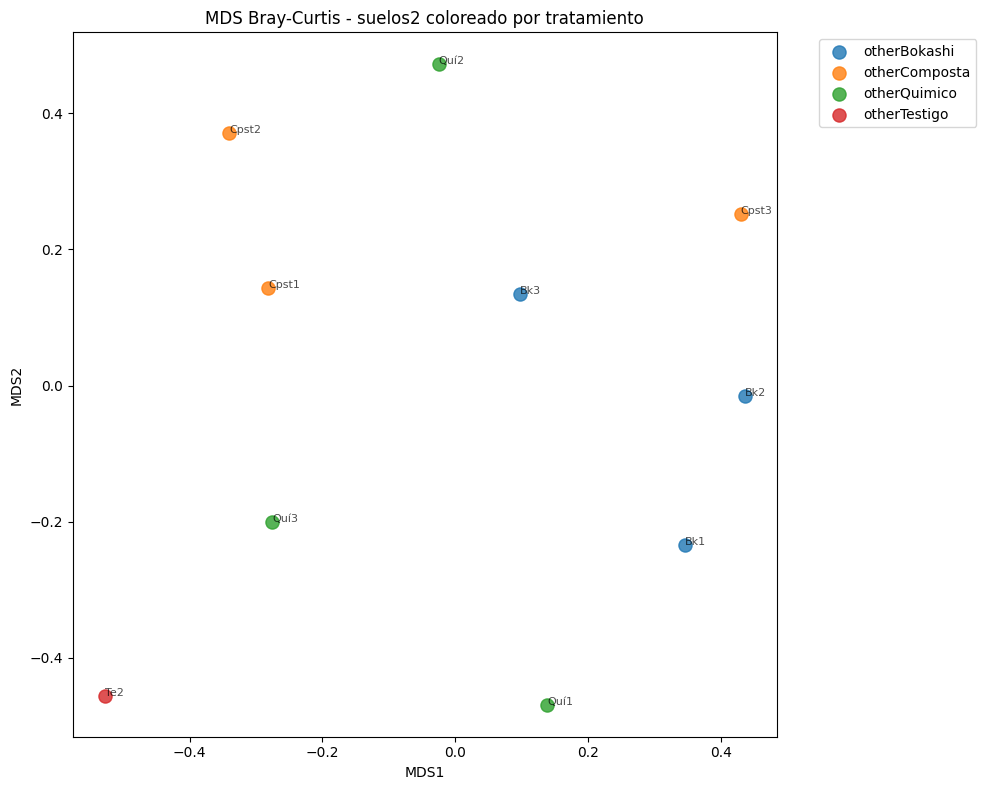

Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos3_mds_braycurtis_por_tratamiento.png
Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos3_mds_braycurtis_por_tratamiento.svg


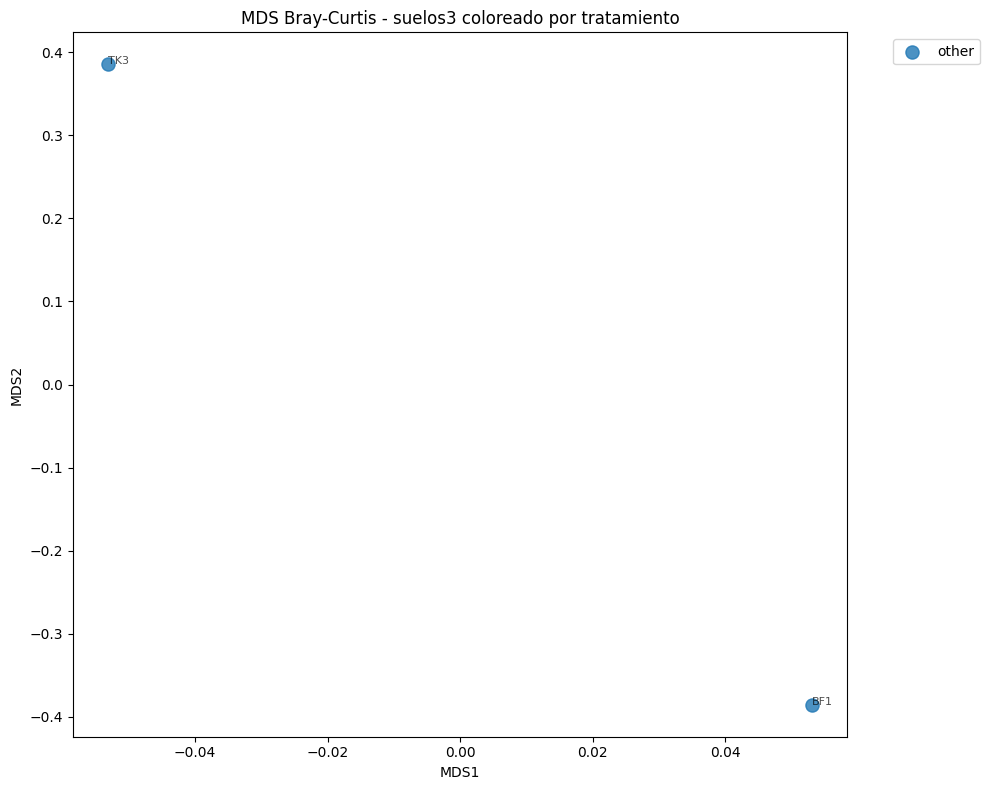

In [11]:
def bray_curtis_distance(otu_table_df):
    data_matrix = otu_table_df.T.values.astype(float)
    distances = pdist(data_matrix, metric="braycurtis")
    return squareform(distances)

def get_plot_label(row, label_col="nombre"):
    if label_col in row and pd.notna(row[label_col]) and str(row[label_col]).strip() != "":
        return str(row[label_col])
    return str(row["sample"])

def plot_mds_for_dataset(dataset, color_col="tratamiento", label_col="nombre"):
    otu_df = otu_tables[dataset]
    meta = sample_metadata[sample_metadata["dataset"] == dataset].set_index("sample").loc[otu_df.columns].reset_index()

    distance_matrix = bray_curtis_distance(otu_df)
    dist_df = pd.DataFrame(distance_matrix, index=otu_df.columns, columns=otu_df.columns)
    dist_df.to_csv(OUTPUT_DIR / f"{dataset}_braycurtis_distance_matrix.csv")

    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    coords = mds.fit_transform(distance_matrix)

    plot_df = meta.copy()
    plot_df["MDS1"] = coords[:, 0]
    plot_df["MDS2"] = coords[:, 1]
    plot_df[color_col] = plot_df[color_col].fillna("NA").astype(str)

    groups = sorted(plot_df[color_col].unique())

    fig, ax = plt.subplots(figsize=(10, 8))
    for group in groups:
        sub = plot_df[plot_df[color_col] == group]
        ax.scatter(sub["MDS1"], sub["MDS2"], s=90, label=group, alpha=0.8)

    for _, row in plot_df.iterrows():
        ax.text(row["MDS1"], row["MDS2"], get_plot_label(row, label_col), fontsize=8, alpha=0.7)

    ax.set_title(f"MDS Bray-Curtis - {dataset} coloreado por {color_col}")
    ax.set_xlabel("MDS1")
    ax.set_ylabel("MDS2")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    save_plot(fig, f"{dataset}_mds_braycurtis_por_{color_col}")
    plt.show()

for dataset in otu_tables:
    plot_mds_for_dataset(dataset, color_col="tratamiento", label_col="nombre")


## 7. PCA de abundancia relativa

Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos1_pca_abundancia_relativa_por_tratamiento.png
Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos1_pca_abundancia_relativa_por_tratamiento.svg


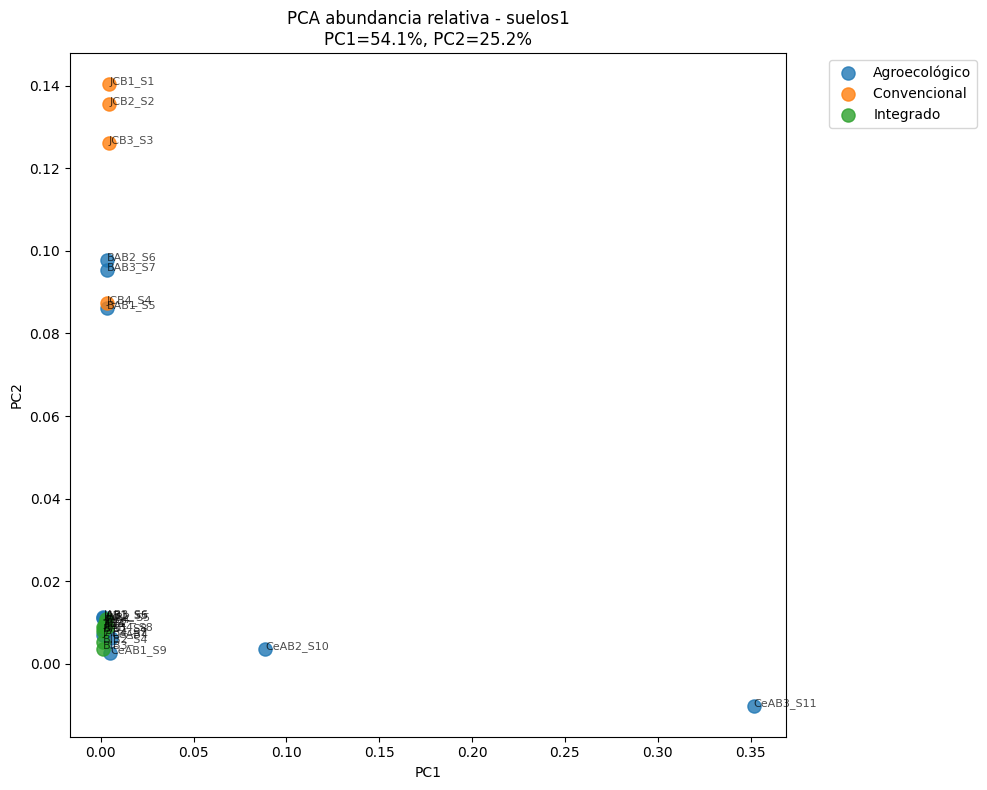

Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos2_pca_abundancia_relativa_por_tratamiento.png
Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos2_pca_abundancia_relativa_por_tratamiento.svg


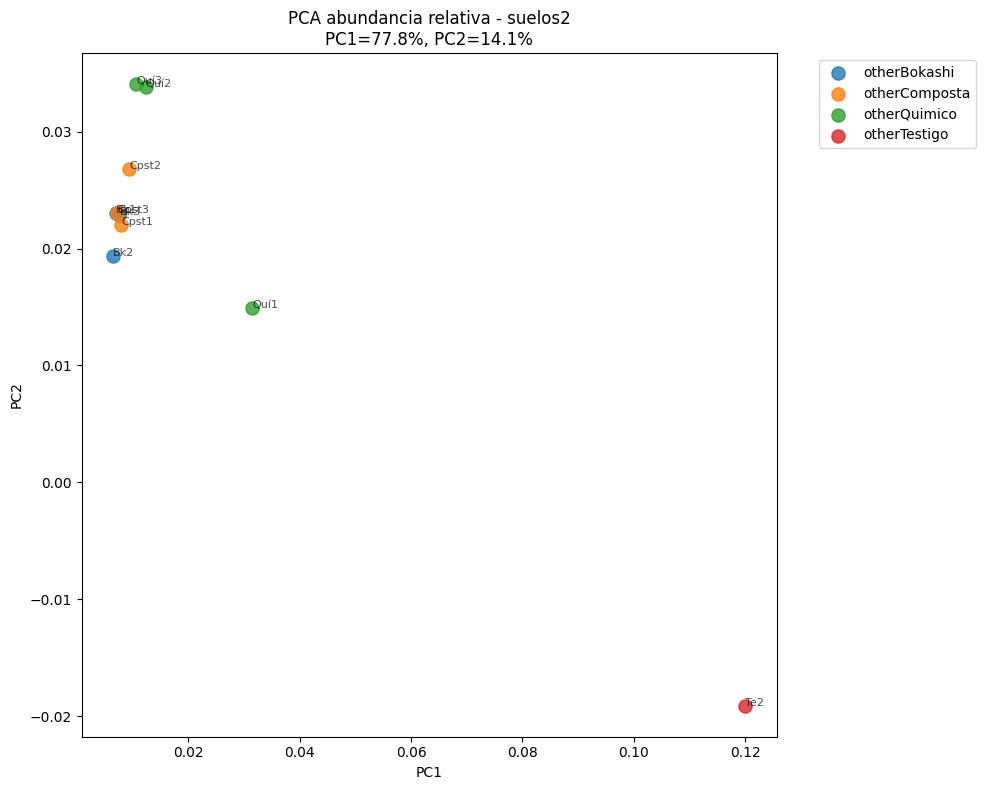

Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos3_pca_abundancia_relativa_por_tratamiento.png
Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos3_pca_abundancia_relativa_por_tratamiento.svg


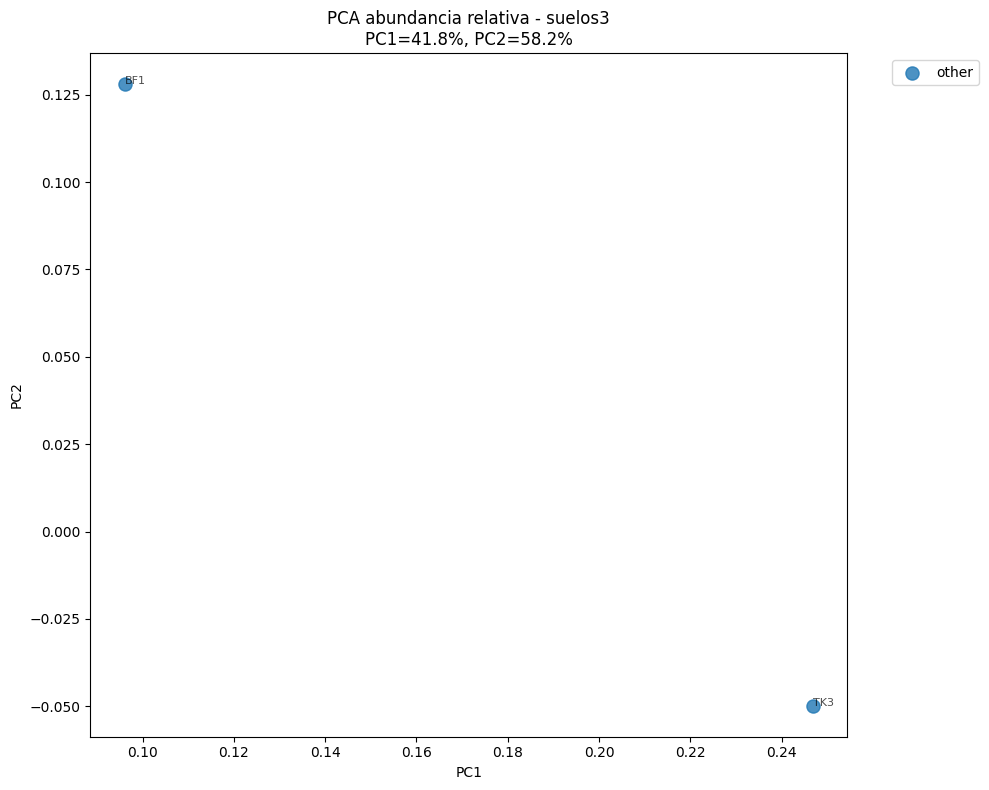

In [18]:
def plot_pca_for_dataset(dataset, color_col="tratamiento", label_col="nombre"):
    otu_df = otu_tables[dataset]
    meta = sample_metadata[sample_metadata["dataset"] == dataset].set_index("sample").loc[otu_df.columns].reset_index()

    mat = otu_df.T.values.astype(float)
    row_sums = mat.sum(axis=1, keepdims=True)
    mat_rel = np.divide(mat, row_sums, out=np.zeros_like(mat), where=row_sums != 0)

    pca = TruncatedSVD(n_components=2, random_state=42)
    coords = pca.fit_transform(mat_rel)

    plot_df = meta.copy()
    plot_df["PC1"] = coords[:, 0]
    plot_df["PC2"] = coords[:, 1]
    plot_df[color_col] = plot_df[color_col].fillna("NA").astype(str)

    groups = sorted(plot_df[color_col].unique())

    fig, ax = plt.subplots(figsize=(10, 8))
    for group in groups:
        sub = plot_df[plot_df[color_col] == group]
        ax.scatter(sub["PC1"], sub["PC2"], s=90, label=group, alpha=0.8)

    for _, row in plot_df.iterrows():
        ax.text(row["PC1"], row["PC2"], get_plot_label(row, label_col), fontsize=8, alpha=0.7)

    ax.set_title(
        f"PCA abundancia relativa - {dataset}\n" # Corrected: Single f-string with embedded newline
        f"PC1={pca.explained_variance_ratio_[0]*100:.1f}%, "
        f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%"
    )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    save_plot(fig, f"{dataset}_pca_abundancia_relativa_por_{color_col}")
    plt.show()

for dataset in otu_tables:
    plot_pca_for_dataset(dataset, color_col="tratamiento", label_col="nombre")

## 8. Composición taxonómica por nivel

Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos1_composicion_taxonomica_phylum_top10.png
Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos1_composicion_taxonomica_phylum_top10.svg


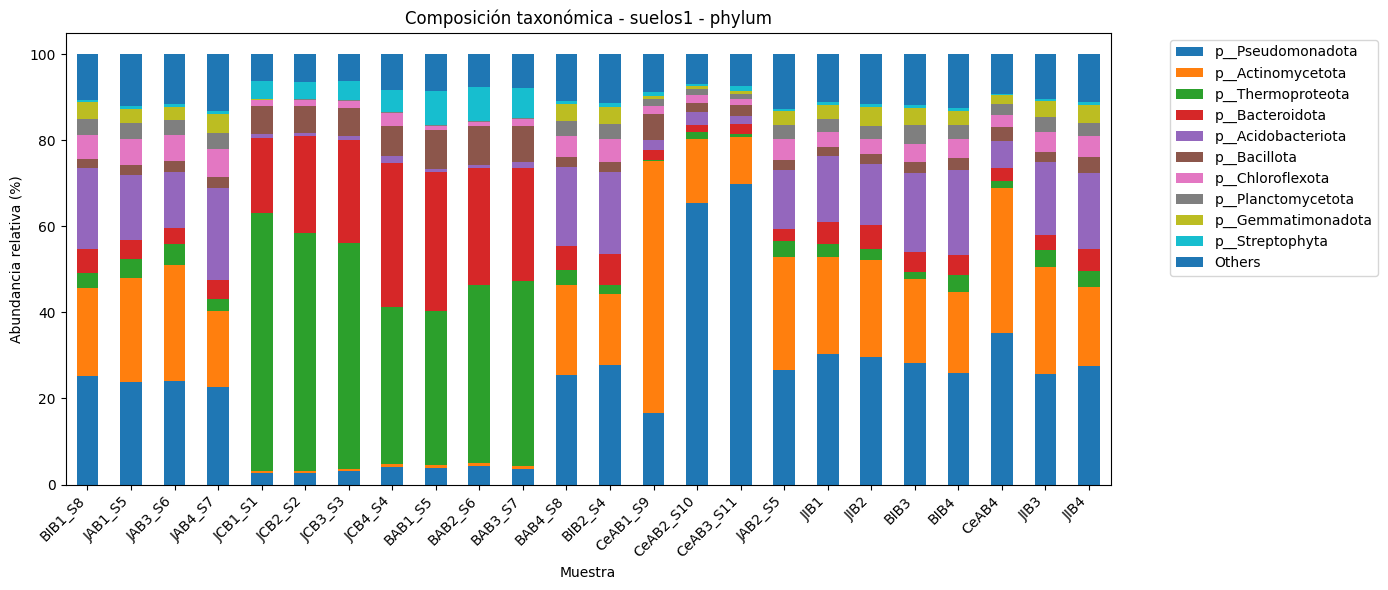

Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos2_composicion_taxonomica_phylum_top10.png
Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos2_composicion_taxonomica_phylum_top10.svg


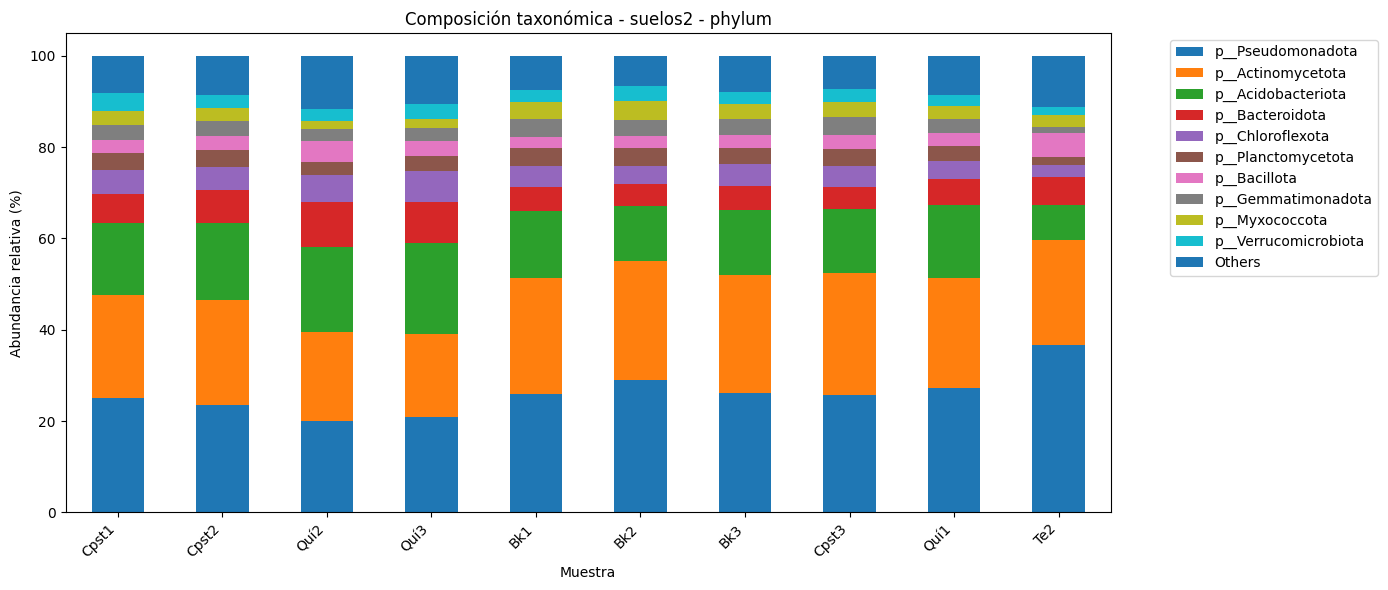

Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos3_composicion_taxonomica_phylum_top10.png
Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos3_composicion_taxonomica_phylum_top10.svg


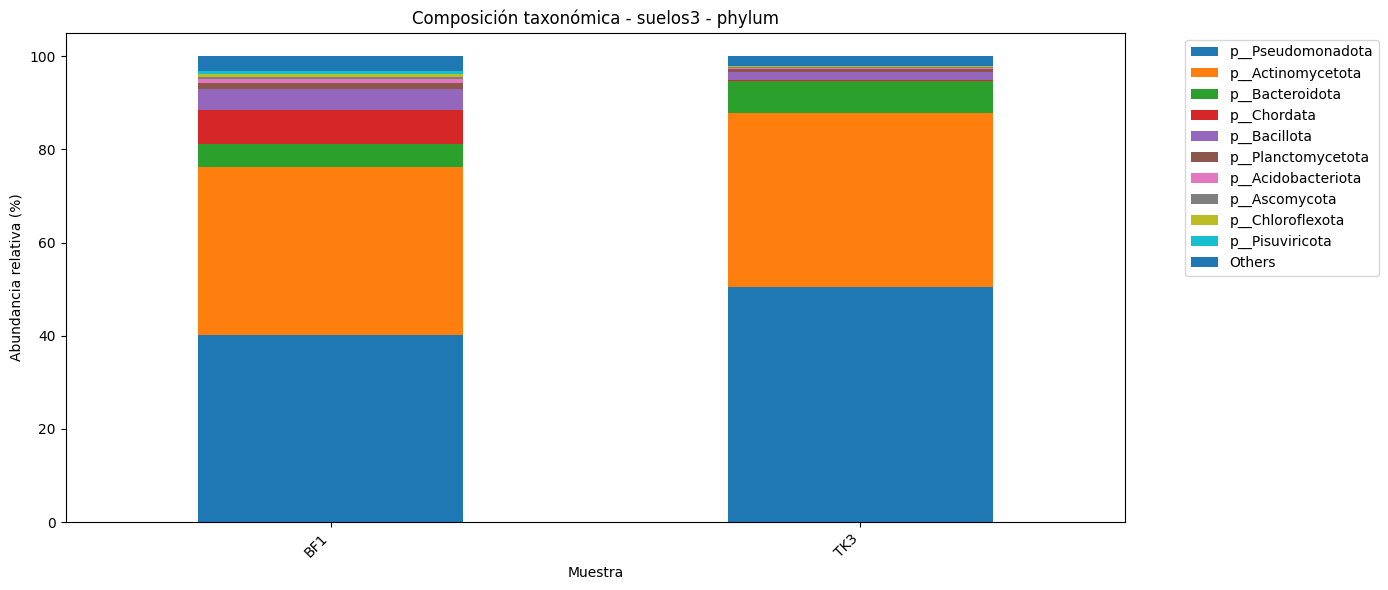

In [13]:
TAX_LEVELS = ["kingdom", "phylum", "class", "order", "family", "genus", "species"]

def aggregate_by_taxonomy(dataset, level="phylum"):
    otu_df = otu_tables[dataset]
    tax_df = taxonomy_tables[dataset][["feature_id", level]].copy()
    tax_df[level] = tax_df[level].fillna("Unclassified").replace("", "Unclassified")

    tmp = otu_df.copy()
    tmp["feature_id"] = tmp.index.astype(str)
    tmp = tmp.merge(tax_df, on="feature_id", how="left")
    abundance = tmp.drop(columns=["feature_id"]).groupby(level).sum()
    return abundance

def sample_labels_for_dataset(dataset, sample_columns):
    meta = sample_metadata[sample_metadata["dataset"] == dataset].set_index("sample")
    labels = []
    for sample in sample_columns:
        if sample in meta.index and "nombre" in meta.columns and pd.notna(meta.loc[sample, "nombre"]):
            labels.append(str(meta.loc[sample, "nombre"]))
        else:
            labels.append(str(sample))
    return labels

def plot_taxonomic_composition(dataset, level="phylum", top_n=12):
    abundance = aggregate_by_taxonomy(dataset, level)
    rel = abundance.div(abundance.sum(axis=0), axis=1) * 100

    top = rel.sum(axis=1).sort_values(ascending=False).head(top_n).index
    plot_df = rel.loc[top].copy()
    plot_df.loc["Others"] = rel.drop(top).sum(axis=0)

    fig, ax = plt.subplots(figsize=(14, 6))
    plot_df.T.plot(kind="bar", stacked=True, ax=ax)
    ax.set_title(f"Composición taxonómica - {dataset} - {level}")
    ax.set_xlabel("Muestra")
    ax.set_ylabel("Abundancia relativa (%)")
    ax.set_xticklabels(sample_labels_for_dataset(dataset, plot_df.columns), rotation=45, ha="right")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    save_plot(fig, f"{dataset}_composicion_taxonomica_{level}_top{top_n}")
    plt.show()

    plot_df.to_csv(OUTPUT_DIR / f"{dataset}_{level}_relative_abundance_top{top_n}.csv")
    return plot_df

for dataset in otu_tables:
    plot_taxonomic_composition(dataset, level="phylum", top_n=10)


Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos1_composicion_taxonomica_genus_top10.png
Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos1_composicion_taxonomica_genus_top10.svg


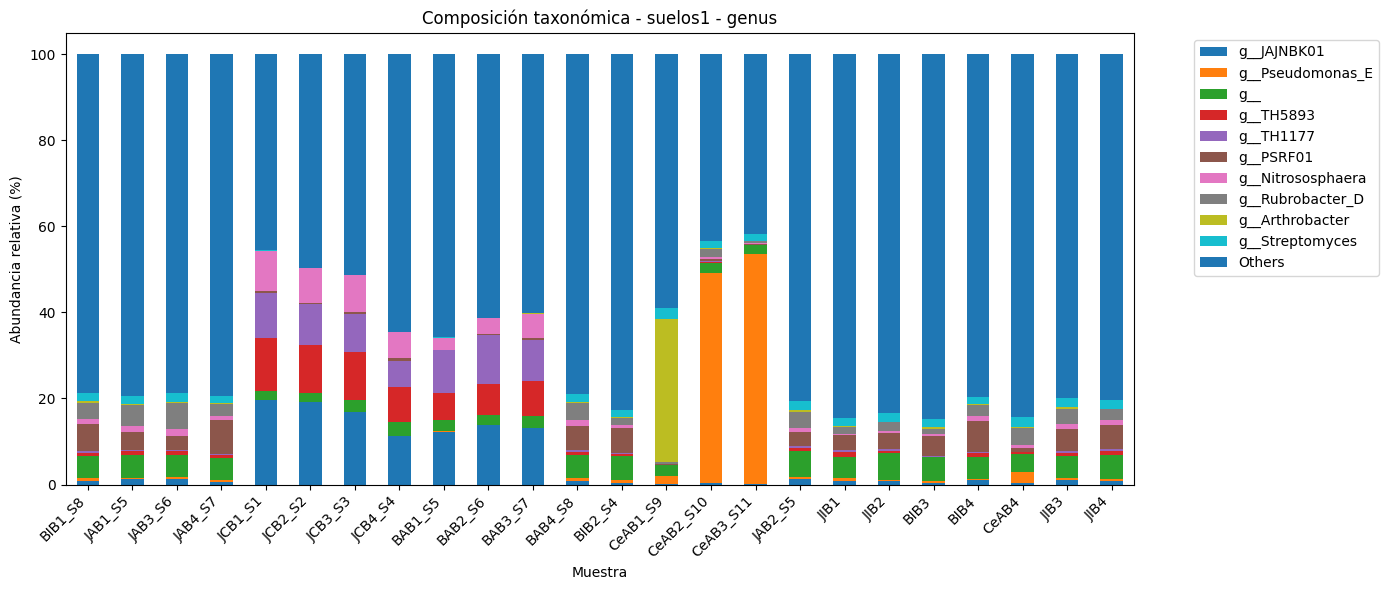

Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos2_composicion_taxonomica_genus_top10.png
Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos2_composicion_taxonomica_genus_top10.svg


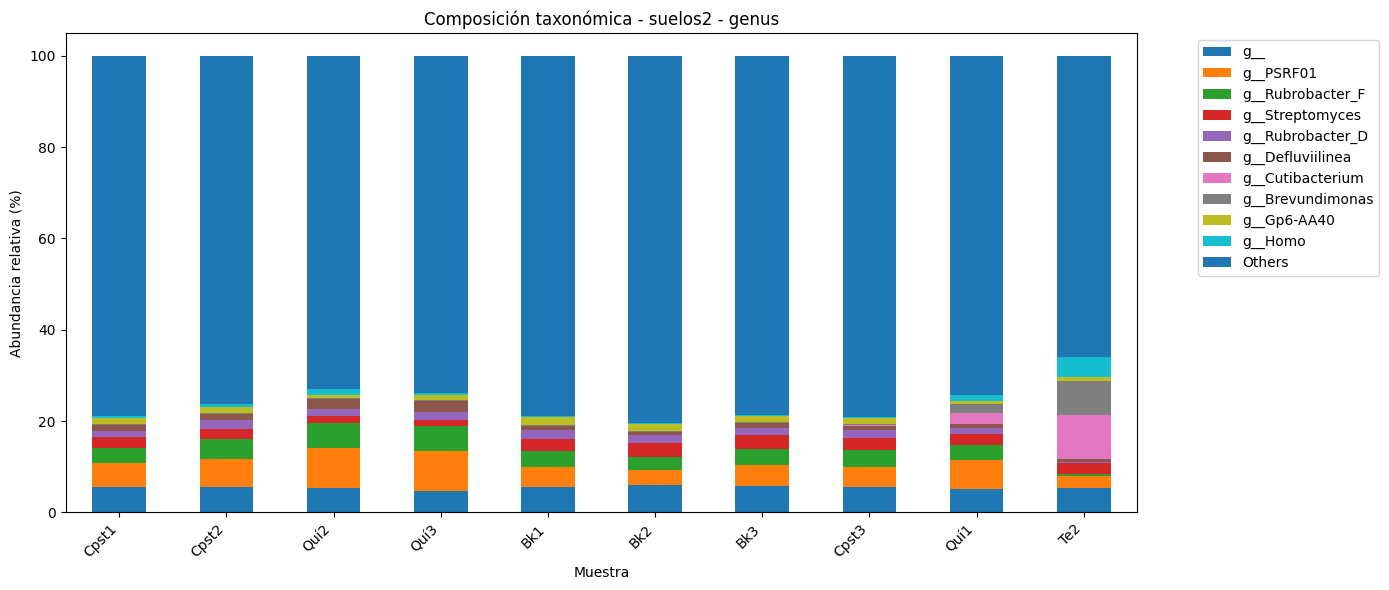

Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos3_composicion_taxonomica_genus_top10.png
Guardado: /content/drive/MyDrive/Luciana/output/plots/suelos3_composicion_taxonomica_genus_top10.svg


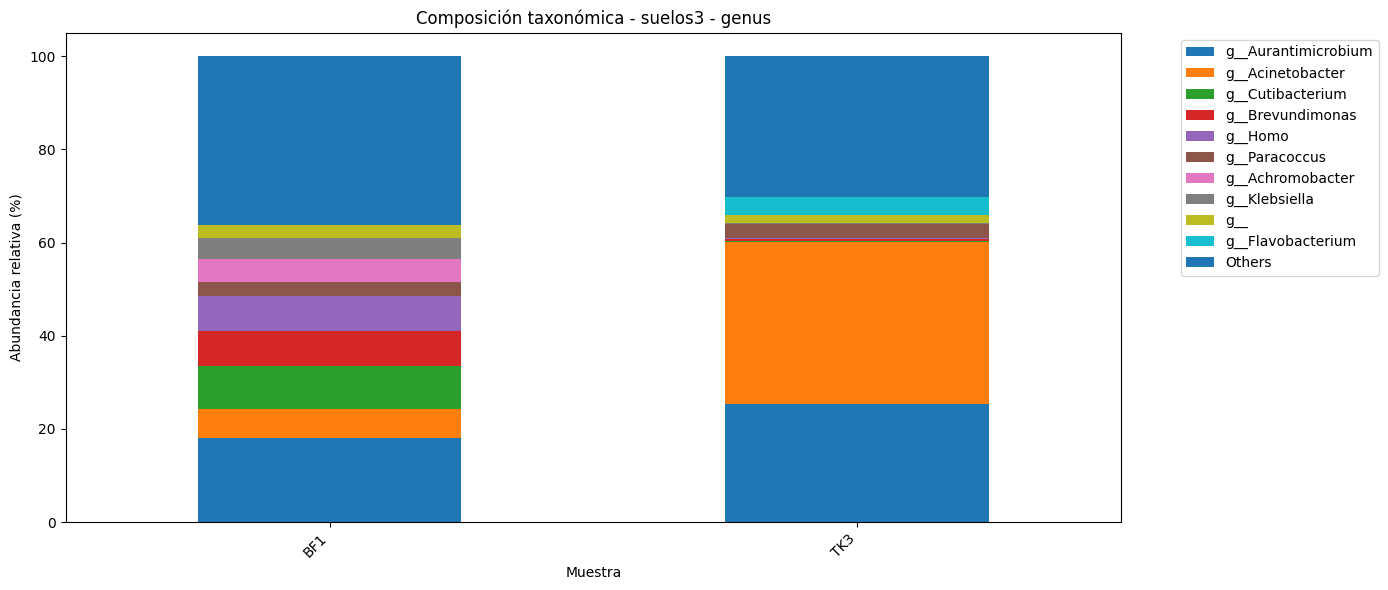

In [17]:
for dataset in otu_tables:
    plot_taxonomic_composition(dataset, level="genus", top_n=10)

## 9. Resumen

In [14]:
summary = (
    alpha_diversity
    .groupby(["dataset", "tratamiento"], dropna=False)
    .agg(
        n=("sample", "count"),
        reads_mean=("total_reads", "mean"),
        observed_mean=("observed", "mean"),
        shannon_mean=("shannon", "mean"),
        simpson_mean=("simpson", "mean"),
    )
    .reset_index()
)

display(summary)
summary.to_csv(OUTPUT_DIR / "resumen_alpha_por_dataset_tratamiento.csv", index=False)

print("Archivos principales guardados en:", OUTPUT_DIR)
print("- sample_info_columnas_originales_biom.csv")
print("- sample_metadata_unida.csv")
print("- alpha_diversity_con_metadata.csv")
print("- resumen_alpha_por_dataset_tratamiento.csv")
print("- *_braycurtis_distance_matrix.csv")
print("- *_relative_abundance_top*.csv")
print("- Gráficas guardadas en plots/ en formatos PNG y SVG")


,dataset,tratamiento,n,reads_mean,observed_mean,shannon_mean,simpson_mean
0,suelos1,Agroecológico,12,5.221693e+05,55228.666667,8.138430,0.983116
1,suelos1,Convencional,4,1.006273e+06,41646.500000,6.794186,0.984299
2,suelos1,Integrado,8,2.699354e+05,33148.375000,8.836380,0.999152
3,suelos2,otherBokashi,3,3.192530e+05,34904.333333,9.213423,0.999369
4,suelos2,otherComposta,3,5.365937e+05,36818.000000,9.178899,0.999252
5,suelos2,otherQuimico,3,4.030733e+05,22508.666667,8.378506,0.998557
6,suelos2,otherTestigo,1,3.470290e+05,13910.000000,6.578503,0.985219
7,suelos3,other,2,5.642380e+05,20154.000000,5.127409,0.955489


Archivos principales guardados en: /content/drive/MyDrive/Luciana/output/resultados_suelos
- sample_info_columnas_originales_biom.csv
- sample_metadata_unida.csv
- alpha_diversity_con_metadata.csv
- resumen_alpha_por_dataset_tratamiento.csv
- *_braycurtis_distance_matrix.csv
- *_relative_abundance_top*.csv
- Gráficas guardadas en plots/ en formatos PNG y SVG
